# 06 — Komparasi Model dan Techno-Economic Assessment (TEA)

Notebook ini merupakan notebook penutup yang menggabungkan hasil kedua algoritma dan menerjemahkannya ke dalam analisis kelayakan ekonomi. Notebook ini memiliki empat tujuan utama:

1. Membandingkan performa model **LightGBM** (notebook `04`) dan **XGBoost** (notebook `05`) pada skenario fitur METEO dan FULL, termasuk uji signifikansi statistik.
2. Memilih model terbaik sebagai dasar estimasi sumber daya surya.
3. Menjalankan analisis *Techno-Economic Assessment* (TEA) PLTS Atap berdasarkan prediksi GHI, dengan fokus pada dua indikator utama: **AEP** (produksi energi tahunan) dan **NPV** (*Net Present Value*).
4. Melakukan analisis sensitivitas terhadap parameter ekonomi utama.

> **Catatan mengenai *circularity*:** skenario FULL menggunakan fitur `DNI` dan `DHI` yang merupakan komponen penyusun GHI, sehingga akurasinya tinggi secara artifisial. Oleh karena itu, analisis TEA menggunakan skenario **METEO** agar estimasi sumber daya bersifat jujur dan tidak bias optimistis.


## 1. Persiapan dan Pemuatan Seluruh Hasil Model

Tahap ini memuat seluruh artefak hasil pelatihan kedua algoritma, yaitu metrik evaluasi (`*_results.json`) dan hasil prediksi pada data uji (`*_predictions.csv`) untuk LightGBM dan XGBoost. Artefak ini menjadi dasar seluruh proses komparasi dan analisis pada notebook ini.


In [1]:
import json
import os

# Fungsi untuk membaca file json hasil eksperimen
def cetak_best_params(nama_file, algoritma):
    if os.path.exists(nama_file):
        with open(nama_file, 'r') as f:
            data = json.load(f)
            print(f"--- Best Hyperparameters {algoritma} ---")
            # Sesuaikan key 'best_params' dengan struktur json Anda
            for k, v in data.get('best_params', {}).items():
                print(f"{k} : {v}")
            print("\n")
    else:
        print(f"File {nama_file} belum ada/tidak ditemukan.")

# Ganti path ini sesuai dengan folder tempat Anda menyimpan hasilnya (biasanya di folder results/ atau models/)
cetak_best_params('../data/results/lightgbm_results.json', 'LightGBM')
cetak_best_params('../data/results/xgboost_results.json', 'XGBoost')

--- Best Hyperparameters LightGBM ---


--- Best Hyperparameters XGBoost ---




In [2]:
# Import library yang dibutuhkan
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon


# Atur tema visualisasi
sns.set_theme(
    style="whitegrid",
    context="notebook",
)

# Atur resolusi gambar
plt.rcParams["figure.dpi"] = 110

# Atur judul grafik menjadi tebal
plt.rcParams["axes.titleweight"] = "bold"

# Atur pandas supaya menampilkan seluruh kolom
pd.set_option("display.max_columns", None)

# Atur lebar output agar tidak terpotong
pd.set_option("display.width", 140)


# Resolusi path agar robust terhadap working directory
candidate_dirs = [
    Path("../data/processed"),
    Path("ml/data/processed"),
    Path("data/processed"),
]

DIR_PROCESSED = next(
    (path for path in candidate_dirs if path.exists()),
    candidate_dirs[0],
)

DIR_RESULTS = DIR_PROCESSED.parent / "results"
DIR_MODELS = DIR_PROCESSED.parent.parent / "models"


# Daftar algoritma yang dibandingkan
ALGORITHMS = ["lightgbm", "xgboost"]


# Muat metrik evaluasi (results.json) tiap algoritma
model_results = {}

for algorithm in ALGORITHMS:

    results_path = (
        DIR_RESULTS /
        f"{algorithm}_results.json"
    )

    with open(results_path, encoding="utf-8") as file:
        model_results[algorithm] = json.load(file)


# Muat prediksi data uji (predictions.csv) tiap algoritma
predictions = {}

for algorithm in ALGORITHMS:

    predictions_path = (
        DIR_RESULTS /
        f"{algorithm}_predictions.csv"
    )

    df_pred = pd.read_csv(predictions_path)
    df_pred["date"] = pd.to_datetime(df_pred["date"])
    predictions[algorithm] = df_pred


# Tampilkan ringkasan hasil yang dimuat
print("Hasil dimuat untuk:", ALGORITHMS)

for algorithm in ALGORITHMS:
    scenarios = list(model_results[algorithm]["scenarios"])
    print(
        f"  {algorithm:9s}: "
        f"skenario {scenarios} | "
        f"prediksi {predictions[algorithm].shape[0]:,} baris"
    )


Hasil dimuat untuk: ['lightgbm', 'xgboost']
  lightgbm : skenario ['METEO', 'FULL'] | prediksi 29,200 baris
  xgboost  : skenario ['METEO', 'FULL'] | prediksi 29,200 baris


## 2. Tabel Komparasi Metrik

Tahap ini menyusun rekapitulasi metrik evaluasi pada data pengujian tahun 2025 untuk keempat kombinasi model, yaitu dua algoritma (LightGBM dan XGBoost) dikalikan dua skenario fitur (METEO dan FULL). Tabel ini memberikan gambaran awal mengenai perbedaan performa antar model.


In [3]:
# Kumpulkan satu baris metrik per kombinasi (algoritma, skenario)
rows = []

for algorithm in ALGORITHMS:

    for scenario, info in model_results[algorithm]["scenarios"].items():

        metrics_train = info["metrics_train"]
        metrics_test = info["metrics_test"]

        rows.append({
            "algoritma": algorithm,
            "skenario": scenario,
            "n_fitur": len(info["features"]),
            "cv_rmse": round(info["cv_rmse"], 4),
            "train_RMSE": round(metrics_train["RMSE"], 4),
            "test_RMSE": round(metrics_test["RMSE"], 4),
            "test_MAE": round(metrics_test["MAE"], 4),
            "test_R2": round(metrics_test["R2"], 4),
            "best_iter": info["best_iteration"],
        })


# Susun tabel komparasi dan urutkan berdasarkan skenario dan RMSE uji
comparison = (
    pd.DataFrame(rows)
    .sort_values(["skenario", "test_RMSE"])
    .reset_index(drop=True)
)

comparison


,algoritma,skenario,n_fitur,cv_rmse,train_RMSE,test_RMSE,test_MAE,test_R2,best_iter
0,lightgbm,FULL,13,0.1971,0.1431,0.2152,0.1275,0.9697,109
1,xgboost,FULL,13,0.1972,0.1260,0.2539,0.1297,0.9578,66
2,xgboost,METEO,11,1.0371,0.8991,1.0520,0.7869,0.2760,83
3,lightgbm,METEO,11,1.0329,0.9476,1.0572,0.7931,0.2687,79


## 3. Komparasi Visual dan Uji Statistik

Tahap ini membandingkan metrik antar model secara visual, kemudian menguji signifikansi perbedaan galat prediksi antara LightGBM dan XGBoost pada setiap skenario. Pengujian dilakukan menggunakan uji **Wilcoxon signed-rank** terhadap nilai *absolute error* berpasangan pada setiap sampel. Uji ini dipilih karena tidak mengasumsikan distribusi normal pada galat prediksi.


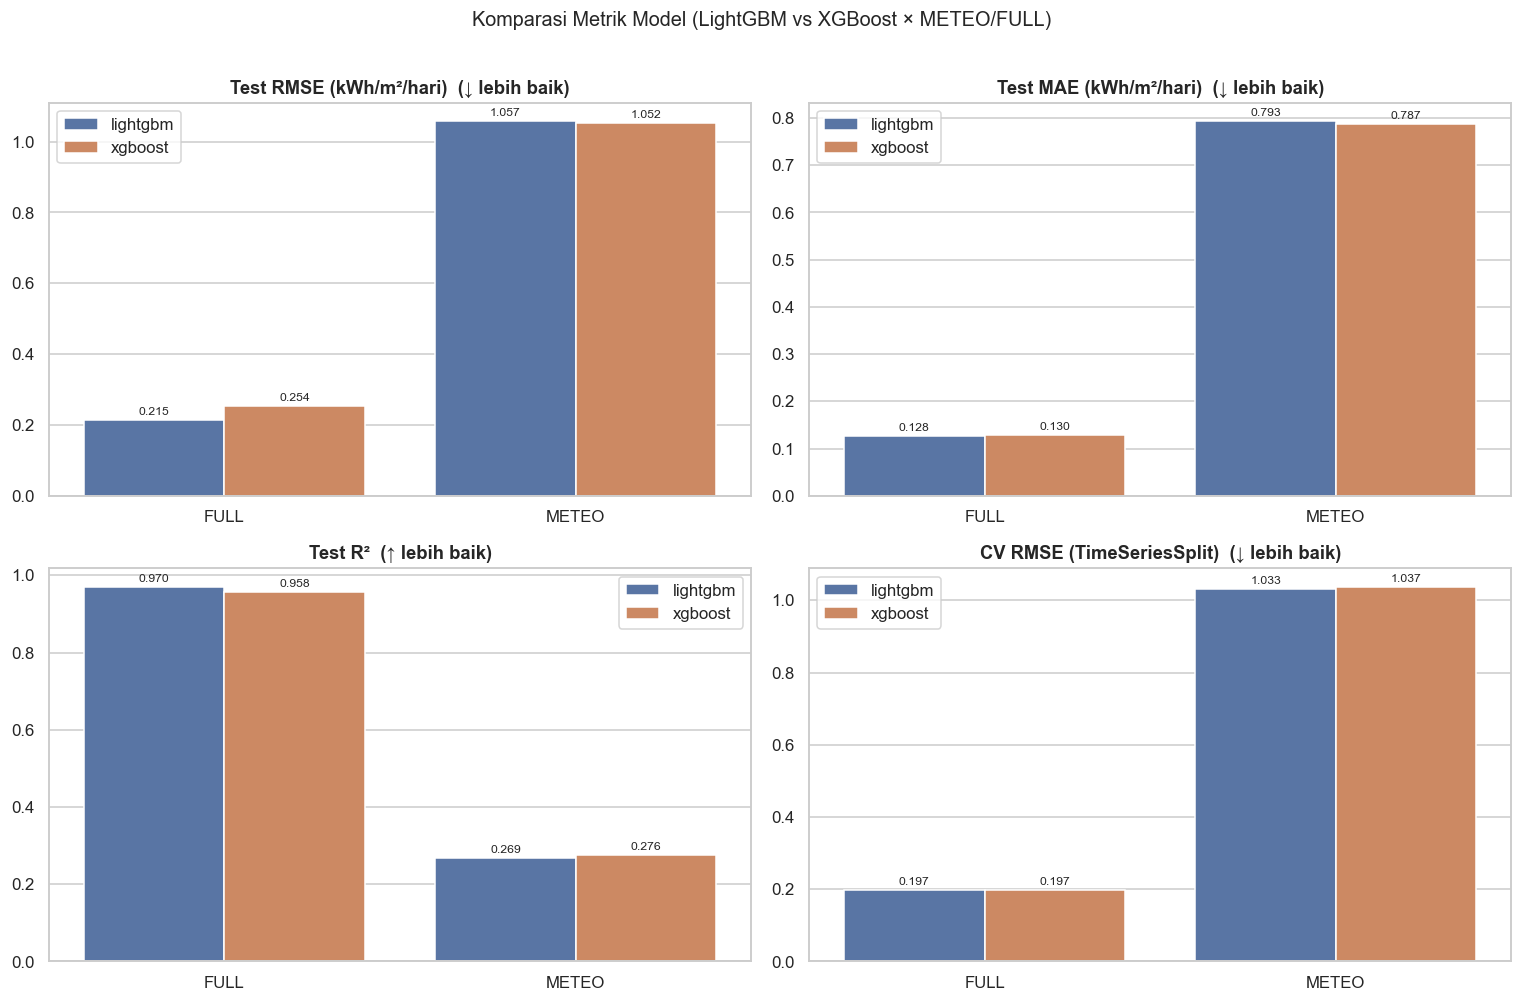

In [4]:
# Bar chart metrik uji (RMSE, MAE, R², CV RMSE) per skenario
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metric_specs = [
    ("test_RMSE", "Test RMSE (kWh/m²/hari)", "lower"),
    ("test_MAE", "Test MAE (kWh/m²/hari)", "lower"),
    ("test_R2", "Test R²", "higher"),
    ("cv_rmse", "CV RMSE (TimeSeriesSplit)", "lower"),
]

for ax, (column, title, direction) in zip(axes.ravel(), metric_specs):

    sns.barplot(
        data=comparison,
        x="skenario",
        y=column,
        hue="algoritma",
        ax=ax,
    )

    if direction == "lower":
        ax.set_title(f"{title}  (↓ lebih baik)")
    else:
        ax.set_title(f"{title}  (↑ lebih baik)")

    ax.set_xlabel("")
    ax.set_ylabel("")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

    ax.legend(title="")

# Kosongkan subplot terakhir jika tidak terpakai
if len(metric_specs) < len(axes.ravel()):
    axes.ravel()[-1].set_visible(False)

fig.suptitle(
    "Komparasi Metrik Model (LightGBM vs XGBoost × METEO/FULL)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.show()

In [5]:
# Uji berpasangan LightGBM vs XGBoost pada |error| tiap sampel
test_rows = []

for scenario in ["METEO", "FULL"]:

    # Ambil prediksi kedua algoritma pada skenario yang sama
    pred_lgb = predictions["lightgbm"]
    pred_xgb = predictions["xgboost"]

    pred_lgb = pred_lgb[pred_lgb["scenario"] == scenario].copy()
    pred_xgb = pred_xgb[pred_xgb["scenario"] == scenario].copy()

    # Gabungkan berdasarkan lokasi dan tanggal agar berpasangan
    merged = pred_lgb.merge(
        pred_xgb,
        on=["location_id", "date"],
        suffixes=("_lgb", "_xgb"),
    )

    # Hitung absolute error tiap sampel
    abs_error_lgb = (merged["y_true_lgb"] - merged["y_pred_lgb"]).abs()
    abs_error_xgb = (merged["y_true_xgb"] - merged["y_pred_xgb"]).abs()

    # Uji Wilcoxon signed-rank pada pasangan absolute error
    statistic, p_value = wilcoxon(abs_error_lgb, abs_error_xgb)

    winner = (
        "LightGBM"
        if abs_error_lgb.mean() < abs_error_xgb.mean()
        else "XGBoost"
    )

    test_rows.append({
        "skenario": scenario,
        "MAE_LightGBM": round(abs_error_lgb.mean(), 4),
        "MAE_XGBoost": round(abs_error_xgb.mean(), 4),
        "selisih_MAE": round(abs_error_lgb.mean() - abs_error_xgb.mean(), 4),
        "wilcoxon_stat": round(statistic, 1),
        "p_value": f"{p_value:.3e}",
        "signifikan_5%": "Ya" if p_value < 0.05 else "Tidak",
        "lebih_baik": winner,
    })


statistical_test = pd.DataFrame(test_rows)

print("Uji Wilcoxon signed-rank (H0: distribusi |error| kedua model identik)\n")
display(statistical_test)


Uji Wilcoxon signed-rank (H0: distribusi |error| kedua model identik)



,skenario,MAE_LightGBM,MAE_XGBoost,selisih_MAE,wilcoxon_stat,p_value,signifikan_5%,lebih_baik
0,METEO,0.7931,0.7869,0.0062,50425362.0,1.781e-08,Ya,XGBoost
1,FULL,0.1275,0.1297,-0.0022,52292720.0,4.937e-02,Ya,LightGBM


## 4. Pemilihan Model Terbaik

Tahap ini menentukan model terbaik berdasarkan dua kriteria, yaitu nilai RMSE pengujian terendah pada setiap skenario dan penggunaan skenario METEO sebagai basis analisis TEA. Skenario METEO dipilih karena bersifat jujur, sedangkan skenario FULL bersifat *circular* akibat hubungan $GHI = DHI + DNI \cdot \cos\theta_z$. Plot *parity* di bawah memvisualisasikan kualitas prediksi setiap model.


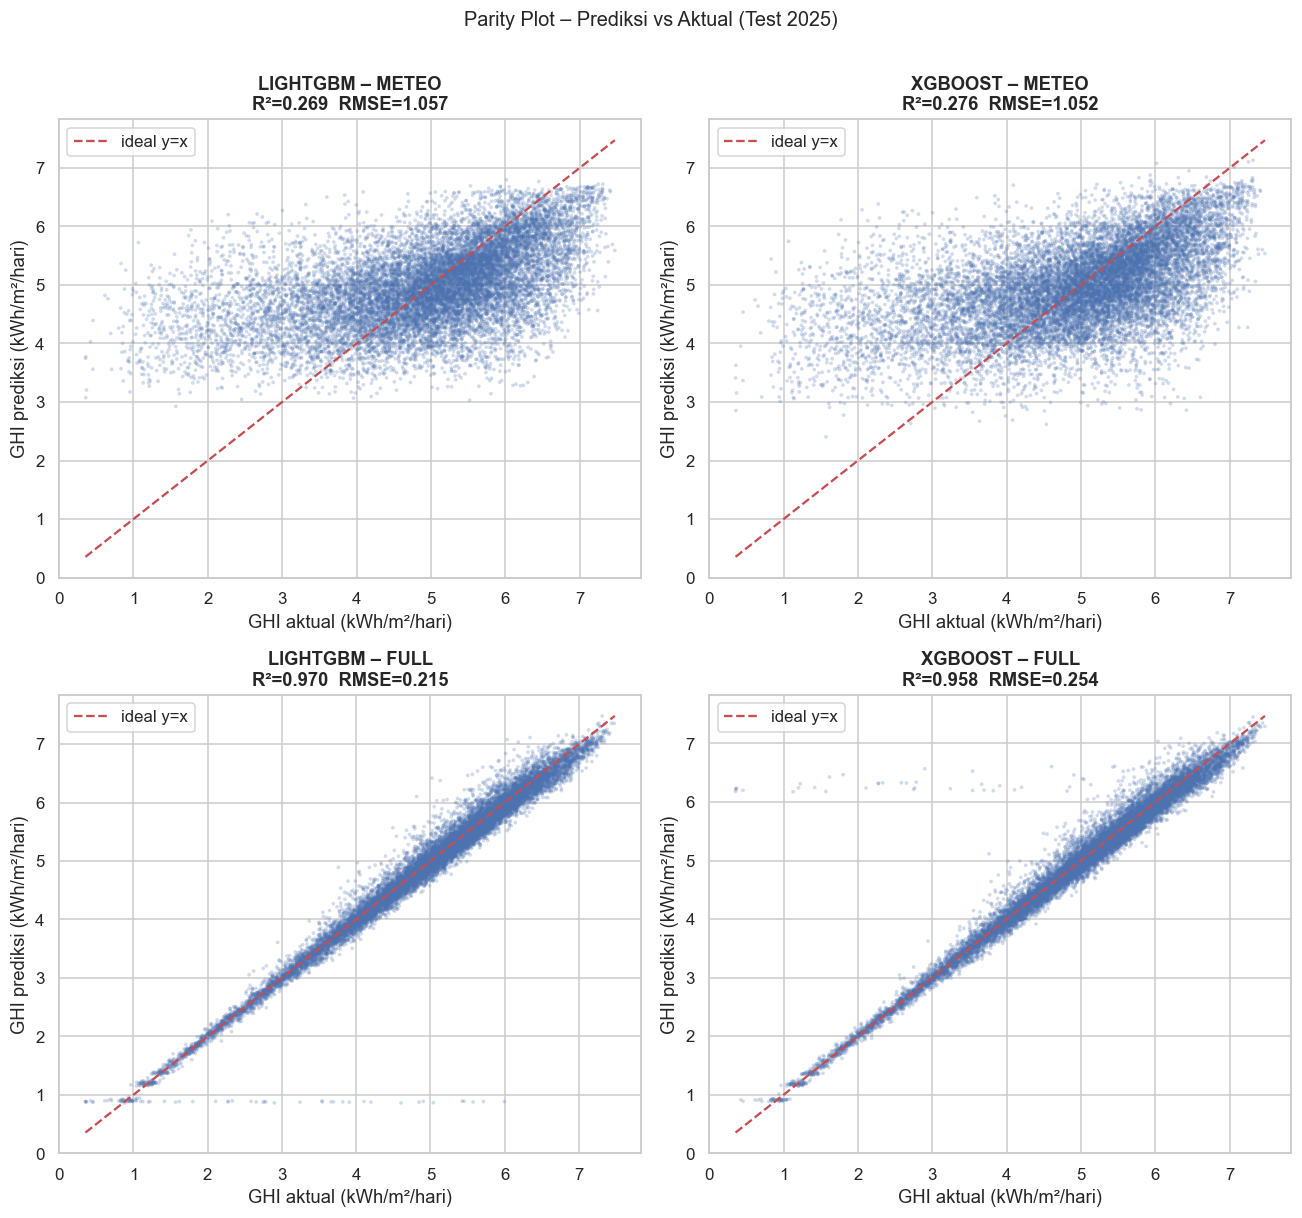

In [6]:
# Parity plot (prediksi vs aktual) untuk 4 model
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

model_scenarios = [
    ("lightgbm", "METEO"),
    ("xgboost", "METEO"),
    ("lightgbm", "FULL"),
    ("xgboost", "FULL"),
]

for ax, (algorithm, scenario) in zip(axes.ravel(), model_scenarios):

    data_plot = predictions[algorithm]
    data_plot = data_plot[data_plot["scenario"] == scenario]

    ax.scatter(
        data_plot["y_true"],
        data_plot["y_pred"],
        s=6,
        alpha=0.25,
        edgecolor="none",
    )

    # Garis ideal y = x
    low = min(data_plot["y_true"].min(), data_plot["y_pred"].min())
    high = max(data_plot["y_true"].max(), data_plot["y_pred"].max())
    ax.plot([low, high], [low, high], "r--", lw=1.5, label="ideal y=x")

    r2 = model_results[algorithm]["scenarios"][scenario]["metrics_test"]["R2"]
    rmse = model_results[algorithm]["scenarios"][scenario]["metrics_test"]["RMSE"]

    ax.set_title(f"{algorithm.upper()} – {scenario}\nR²={r2:.3f}  RMSE={rmse:.3f}")
    ax.set_xlabel("GHI aktual (kWh/m²/hari)")
    ax.set_ylabel("GHI prediksi (kWh/m²/hari)")
    ax.legend(loc="upper left")

fig.suptitle("Parity Plot – Prediksi vs Aktual (Test 2025)", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


In [7]:
# Tetapkan model terbaik tiap skenario (RMSE uji terendah)
best_per_scenario = {}

for scenario in ["METEO", "FULL"]:

    subset = comparison[comparison["skenario"] == scenario]
    best_row = subset.loc[subset["test_RMSE"].idxmin()]
    best_per_scenario[scenario] = best_row["algoritma"]


print("Model terbaik per skenario (test RMSE terendah):")

for scenario, algorithm in best_per_scenario.items():
    print(f"  • {scenario:6s}: {algorithm.upper()}")


# Model untuk TEA = LightGBM pada skenario METEO.
# METEO dipakai agar estimasi sumber daya tidak circular; LightGBM dipakai
# sebagai model implementasi TEA yang ditetapkan pada tahap sebelumnya.
TEA_SCENARIO = "METEO"
TEA_ALGO = "lightgbm"

print(f"\n>>> Model untuk TEA: {TEA_ALGO.upper()} – skenario {TEA_SCENARIO}")
print("    (METEO dipilih agar estimasi sumber daya tidak bersifat circular)")


Model terbaik per skenario (test RMSE terendah):
  • METEO : XGBOOST
  • FULL  : LIGHTGBM

>>> Model untuk TEA: LIGHTGBM – skenario METEO
    (METEO dipilih agar estimasi sumber daya tidak bersifat circular)


## 5. Parameter dan Asumsi TEA

Tahap ini mendefinisikan seluruh parameter dan asumsi yang digunakan dalam analisis *Techno-Economic Assessment*. Metodologi telah diperbaiki sesuai standar pemodelan performa PV yang berlaku internasional (IEC 61724, PVLIB):

**Perbaikan utama terhadap versi sebelumnya:**

1. **Multi-year baseline**: Produksi energi multi-tahun (2021–2025) dihitung sebagai *backtest* pembanding; adapun basis produksi Year-1 untuk TEA menggunakan forecast tahun 2026 (Tahap 6c).
2. **Transposisi POA**: GHI tidak langsung dikonversi ke energi. Ditambahkan tahap standar: Solar Position → Dekomposisi (Erbs) → Transposisi POA (Perez) → Effective Irradiance → PV Performance.
3. **Statistik variabilitas**: Dilaporkan mean, standar deviasi, dan koefisien variasi (CV) sebagai ukuran ketidakpastian sumber daya surya.

**Parameter sistem PV:**
- Kapasitas: 5 kWp, tilt 10° (optimal tropis), azimuth 0° (menghadap utara, karena lokasi di belahan bumi selatan)
- CAPEX Rp 15 juta/kWp, tarif listrik Rp 1.444,70/kWh (R-1 non-subsidi)
- Umur proyek 25 tahun, discount rate 6%, degradasi modul 0,5%/tahun

**Model transposisi:** Perez et al. (1990) dipilih karena merupakan model transposisi paling banyak divalidasi untuk iklim tropis dan direkomendasikan oleh IEA-PVPS Task 16.

In [8]:
# ============================================================
#  PARAMETER TEA  (ubah di sini untuk skenario lain)
# ============================================================

# --- Parameter Sistem PV ---
CAPACITY_KWP = 5.0                # Kapasitas terpasang (kWp)
TILT = 10.0                       # Sudut kemiringan modul (derajat) – optimal tropis
AZIMUTH = 0.0                     # Azimuth modul (0°=utara, karena lintang selatan)
ALBEDO = 0.2                      # Albedo permukaan sekitar (beton/rumput)

# --- Parameter Ekonomi ---
CAPEX_PER_KWP = 15_000_000       # CAPEX per kWp (Rp)
TARIFF = 1_444.70                 # Tarif listrik (Rp/kWh, R-1 non-subsidi)
LIFETIME_YEARS = 25               # Umur proyek (tahun)
DISCOUNT_RATE = 0.06              # Discount rate riil
DEGRADATION = 0.005               # Degradasi modul per tahun (0.5%)

# --- Asumsi Sekunder ---
PERFORMANCE_RATIO = 0.80          # Performance ratio sistem (memperhitungkan losses)
SELF_CONSUMPTION = 0.65           # Fraksi energi yang dipakai sendiri
OPEX_RATE = 0.01                  # OPEX = 1% CAPEX per tahun
TARIFF_ESCALATION = 0.03          # Eskalasi tarif listrik per tahun

# --- Turunan Parameter ---
CAPEX_TOTAL = CAPACITY_KWP * CAPEX_PER_KWP
OPEX_ANNUAL = OPEX_RATE * CAPEX_TOTAL

# --- Koordinat Lokasi Target ---
TARGET_LAT = -6.2
TARGET_LON = 106.8
TARGET_NAME = "Jakarta"

# --- Tahun yang tersedia ---
ALL_YEARS = [2021, 2022, 2023, 2024, 2025]

# Tampilkan ringkasan parameter
print("=" * 60)
print("PARAMETER TECHNO-ECONOMIC ASSESSMENT")
print("=" * 60)
print(f"Lokasi target    : {TARGET_NAME} ({TARGET_LAT}°, {TARGET_LON}°)")
print(f"Kapasitas        : {CAPACITY_KWP} kWp")
print(f"Tilt / Azimuth   : {TILT}° / {AZIMUTH}° (menghadap utara)")
print(f"CAPEX total      : Rp {CAPEX_TOTAL:,.0f}")
print(f"OPEX tahunan     : Rp {OPEX_ANNUAL:,.0f}")
print(f"PR               : {PERFORMANCE_RATIO}")
print(f"Self-consumption : {SELF_CONSUMPTION}")
print(f"Degradasi        : {DEGRADATION*100:.1f}%/tahun")
print(f"Discount rate    : {DISCOUNT_RATE*100:.0f}%")
print(f"Tahun analisis   : {ALL_YEARS}")
print(f"\nBaseline Year-1  : Forecast 2026 (climatology-based); multi-tahun sbg backtest")

PARAMETER TECHNO-ECONOMIC ASSESSMENT
Lokasi target    : Jakarta (-6.2°, 106.8°)
Kapasitas        : 5.0 kWp
Tilt / Azimuth   : 10.0° / 0.0° (menghadap utara)
CAPEX total      : Rp 75,000,000
OPEX tahunan     : Rp 750,000
PR               : 0.8
Self-consumption : 0.65
Degradasi        : 0.5%/tahun
Discount rate    : 6%
Tahun analisis   : [2021, 2022, 2023, 2024, 2025]

Baseline Year-1  : Forecast 2026 (climatology-based); multi-tahun sbg backtest


## 6. Model Produksi Energi dengan Transposisi POA (Multi-Year)

Tahap ini menghitung produksi energi sistem PLTS Atap menggunakan pipeline yang sesuai standar pemodelan performa PV:

$$
\text{GHI}_{\text{pred}} \xrightarrow{\text{Erbs}} \text{DNI, DHI} \xrightarrow{\text{Solar Position}} \xrightarrow{\text{Perez}} \text{POA/IPOA} \xrightarrow{\text{PR}} \text{AEP}
$$

**Langkah-langkah:**
1. Muat model ML terbaik dan prediksi GHI untuk **seluruh tahun** (2021–2025)
2. Hitung posisi matahari (solar zenith, azimuth) menggunakan algoritma NREL SPA
3. Dekomposisi GHI menjadi DNI dan DHI menggunakan model **Erbs** (1982)
4. Transposisi ke bidang modul (POA) menggunakan model **Perez** (1990)
5. Hitung produksi energi tahunan (AEP) untuk setiap tahun
6. Hitung statistik multi-tahun: mean, std, CV

**Mengapa model Erbs?** Model Erbs merupakan model dekomposisi korelasi (*separation model*) yang menghubungkan fraksi diffuse ($k_d$) dengan *clearness index* ($k_t$). Model ini sederhana, robust, dan banyak digunakan dalam literatur PV ketika hanya GHI yang tersedia.

**Mengapa model Perez?** Model Perez membagi radiasi diffuse menjadi tiga komponen (circumsolar, horizon brightening, isotropic) dan telah divalidasi secara ekstensif di berbagai iklim. Model ini direkomendasikan oleh IEA-PVPS dan NREL untuk simulasi performa PV.

In [9]:
# ============================================================
#  6a. Muat Model dan Prediksi GHI Seluruh Tahun (2021-2025)
# ============================================================

import pvlib
from pvlib.location import Location
from pvlib.irradiance import get_total_irradiance, erbs

import joblib


# Muat dataset fitur lengkap (seluruh tahun)
features_path = DIR_PROCESSED / "features_dataset.csv"
parquet_path = DIR_PROCESSED / "features_dataset.parquet"

if parquet_path.exists():
    df_full = pd.read_parquet(parquet_path)
else:
    df_full = pd.read_csv(features_path, parse_dates=["date"])

df_full["date"] = pd.to_datetime(df_full["date"])


# Muat konfigurasi fitur
import json
config_path = DIR_PROCESSED / "feature_config.json"
with open(config_path, encoding="utf-8") as f:
    feature_config = json.load(f)

METEO_FEATURES = feature_config["feature_sets"]["METEO"]
TARGET = feature_config["target"]


# Muat model terbaik (skenario METEO)
model_path = DIR_PROCESSED.parent / "models" / f"{TEA_ALGO}_METEO.pkl"

if not model_path.exists():
    # Fallback: cari di DIR_MODELS
    model_path = DIR_RESULTS.parent.parent / "models" / f"{TEA_ALGO}_METEO.pkl"

tea_model = joblib.load(model_path)
print(f"Model dimuat: {model_path.name} ({TEA_ALGO.upper()} – METEO)")


# Identifikasi grid terdekat ke lokasi target
def parse_lat_lon(location_id):
    """Pisahkan location_id 'lat_lon' menjadi (lat, lon)."""
    lat_str, lon_str = str(location_id).split("_")
    return float(lat_str), float(lon_str)


locations = (
    df_full["location_id"]
    .drop_duplicates()
    .to_frame()
    .assign(
        lat=lambda d: d["location_id"].map(lambda x: parse_lat_lon(x)[0]),
        lon=lambda d: d["location_id"].map(lambda x: parse_lat_lon(x)[1]),
    )
)

locations["dist"] = np.hypot(
    locations["lat"] - TARGET_LAT,
    locations["lon"] - TARGET_LON,
)

nearest = locations.loc[locations["dist"].idxmin()]
TARGET_LOC_ID = nearest["location_id"]

print(f"Lokasi target  : {TARGET_NAME} ({TARGET_LAT}°, {TARGET_LON}°)")
print(f"Grid terdekat  : {TARGET_LOC_ID} (lat={nearest['lat']}, lon={nearest['lon']})")


# Prediksi GHI untuk seluruh tahun pada lokasi target
site_data = df_full[df_full["location_id"] == TARGET_LOC_ID].copy()
site_data = site_data.sort_values("date").reset_index(drop=True)

# Prediksi GHI menggunakan model METEO
X_site = site_data[METEO_FEATURES]
site_data["GHI_pred"] = tea_model.predict(X_site)

# Pastikan GHI prediksi tidak negatif (secara fisik tidak mungkin)
site_data["GHI_pred"] = site_data["GHI_pred"].clip(lower=0)

# Tambahkan kolom tahun
site_data["year"] = site_data["date"].dt.year

print(f"\nJumlah hari total: {len(site_data)}")
print(f"Tahun tersedia   : {sorted(site_data['year'].unique())}")
print(f"GHI prediksi (rata-rata harian): {site_data['GHI_pred'].mean():.3f} kWh/m²/hari")

Model dimuat: lightgbm_METEO.pkl (LIGHTGBM – METEO)
Lokasi target  : Jakarta (-6.2°, 106.8°)
Grid terdekat  : -6.5000_106.5000 (lat=-6.5, lon=106.5)

Jumlah hari total: 1826
Tahun tersedia   : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
GHI prediksi (rata-rata harian): 4.713 kWh/m²/hari


In [10]:
# ============================================================
#  6b. Transposisi POA menggunakan pvlib (Perez model)
# ============================================================
# Pipeline: GHI_pred → Solar Position → Erbs Decomposition → Perez POA → AEP

def calculate_annual_poa_and_aep(
    daily_ghi,
    dates,
    latitude,
    longitude,
    tilt,
    azimuth,
    albedo,
    capacity_kwp,
    pr,
):
    """
    Menghitung Plane-of-Array Irradiance (POA) dan Annual Energy Production (AEP)
    dari data GHI harian menggunakan pipeline standar PV performance modeling.

    Pipeline:
    1. Solar position (NREL SPA via pvlib)
    2. Extraterrestrial irradiance (Spencer, 1971)
    3. Dekomposisi GHI → DNI + DHI (Erbs et al., 1982)
    4. Transposisi ke bidang modul (Perez et al., 1990)
    5. AEP = sum(POA) × capacity × PR / 1000

    Parameters
    ----------
    daily_ghi : array-like, GHI harian (kWh/m²/hari)
    dates : DatetimeIndex, tanggal untuk setiap nilai GHI
    latitude, longitude : float, koordinat lokasi
    tilt : float, sudut kemiringan modul (derajat)
    azimuth : float, azimuth modul (derajat, 0=utara)
    albedo : float, reflektifitas permukaan
    capacity_kwp : float, kapasitas sistem (kWp)
    pr : float, performance ratio

    Returns
    -------
    dict dengan keys: poa_daily, poa_annual, aep_kwh, dni_daily, dhi_daily
    """

    # Buat objek lokasi pvlib
    site = Location(latitude, longitude, tz="Asia/Jakarta")

    # Konversi GHI harian ke W/m² (rata-rata selama jam surya ~10 jam di tropis)
    # Catatan: Untuk data harian, kita gunakan pendekatan instantaneous pada solar noon
    # kemudian koreksi ke total harian menggunakan clear-sky scaling

    results_poa = []
    results_dni = []
    results_dhi = []

    for i, (date, ghi_kwh) in enumerate(zip(dates, daily_ghi)):

        # Solar noon timestamp (representatif untuk data harian)
        noon = pd.Timestamp(date).replace(hour=12, minute=0)
        times = pd.DatetimeIndex([noon], tz="Asia/Jakarta")

        # Posisi matahari pada solar noon
        solpos = site.get_solarposition(times)
        zenith = solpos["apparent_zenith"].iloc[0]
        sol_azimuth = solpos["azimuth"].iloc[0]

        # Skip jika matahari di bawah horizon
        if zenith >= 90:
            results_poa.append(0.0)
            results_dni.append(0.0)
            results_dhi.append(0.0)
            continue

        # Extraterrestrial irradiance (Spencer model)
        doy = pd.Timestamp(date).dayofyear
        dni_extra = pvlib.irradiance.get_extra_radiation(doy)

        # GHI dalam W/m² (instantaneous equivalent at noon)
        # Untuk konversi harian: GHI_daily(kWh/m²) ≈ GHI_noon(W/m²) × day_length / 1000
        # Inversi: GHI_noon ≈ GHI_daily × 1000 / (π/2 × day_length_factor)
        # Pendekatan sederhana: gunakan GHI harian langsung sebagai proxy
        # karena rasio POA/GHI relatif konstan untuk daily data
        cos_zenith = np.cos(np.radians(zenith))

        # Clearness index
        if cos_zenith > 0.05 and dni_extra > 0:
            # GHI dalam kWh/m²/hari → konversi ke W/m² rata-rata daylight
            # Asumsi ~10 jam efektif matahari di tropis
            ghi_wm2 = ghi_kwh * 1000 / 10.0
            kt = ghi_wm2 / (dni_extra * cos_zenith)
            kt = np.clip(kt, 0, 1.0)
        else:
            kt = 0.0
            ghi_wm2 = 0.0

        # Dekomposisi Erbs: GHI → DHI, DNI
        if kt > 0 and ghi_wm2 > 0:
            # Model Erbs (1982) untuk fraksi diffuse
            if kt <= 0.22:
                kd = 1.0 - 0.09 * kt
            elif kt <= 0.80:
                kd = (0.9511 - 0.1604*kt + 4.388*kt**2
                      - 16.638*kt**3 + 12.336*kt**4)
            else:
                kd = 0.165

            dhi_wm2 = kd * ghi_wm2
            # DNI dari relasi: GHI = DNI*cos(zenith) + DHI
            dni_wm2 = (ghi_wm2 - dhi_wm2) / max(cos_zenith, 0.05)
            dni_wm2 = max(dni_wm2, 0)
        else:
            dhi_wm2 = 0.0
            dni_wm2 = 0.0

        # Transposisi Perez ke bidang modul (POA)
        try:
            poa = pvlib.irradiance.get_total_irradiance(
                surface_tilt=tilt,
                surface_azimuth=azimuth,
                solar_zenith=zenith,
                solar_azimuth=sol_azimuth,
                dni=dni_wm2,
                ghi=ghi_wm2,
                dhi=dhi_wm2,
                dni_extra=dni_extra,
                model="perez",
                albedo=albedo,
            )
            poa_wm2 = poa["poa_global"].iloc[0] if hasattr(poa["poa_global"], "iloc") else float(poa["poa_global"])
            poa_wm2 = max(poa_wm2, 0)
        except Exception:
            # Fallback: isotropic model jika Perez gagal
            poa_wm2 = ghi_wm2

        # Konversi POA kembali ke kWh/m²/hari (×10 jam / 1000)
        poa_kwh = poa_wm2 * 10.0 / 1000.0

        results_poa.append(poa_kwh)
        results_dni.append(dni_wm2 * 10.0 / 1000.0)  # kWh/m²/hari
        results_dhi.append(dhi_wm2 * 10.0 / 1000.0)  # kWh/m²/hari

    poa_daily = np.array(results_poa)
    poa_annual = poa_daily.sum()
    aep = capacity_kwp * poa_annual * pr  # kWh/tahun (POA sudah dalam kWh/m²/hari)

    return {
        "poa_daily": poa_daily,
        "poa_annual": poa_annual,
        "aep_kwh": aep,
        "dni_daily": np.array(results_dni),
        "dhi_daily": np.array(results_dhi),
    }


# ============================================================
#  Hitung POA dan AEP per tahun (2021-2025)
# ============================================================

yearly_results = {}

for year in ALL_YEARS:

    year_data = site_data[site_data["year"] == year].copy()

    if len(year_data) == 0:
        print(f"  [!] Tahun {year}: tidak ada data")
        continue

    result = calculate_annual_poa_and_aep(
        daily_ghi=year_data["GHI_pred"].values,
        dates=year_data["date"].values,
        latitude=nearest["lat"],
        longitude=nearest["lon"],
        tilt=TILT,
        azimuth=AZIMUTH,
        albedo=ALBEDO,
        capacity_kwp=CAPACITY_KWP,
        pr=PERFORMANCE_RATIO,
    )

    yearly_results[year] = {
        "n_days": len(year_data),
        "ghi_annual": year_data["GHI_pred"].sum(),
        "ghi_mean_daily": year_data["GHI_pred"].mean(),
        "poa_annual": result["poa_annual"],
        "aep_kwh": result["aep_kwh"],
    }

    print(
        f"  {year}: {len(year_data)} hari | "
        f"GHI={year_data['GHI_pred'].sum():.1f} kWh/m²/thn | "
        f"POA={result['poa_annual']:.1f} kWh/m²/thn | "
        f"AEP={result['aep_kwh']:.0f} kWh"
    )


# ============================================================
#  Statistik Multi-Tahun
# ============================================================

ghi_annual_values = np.array([v["ghi_annual"] for v in yearly_results.values()])
poa_annual_values = np.array([v["poa_annual"] for v in yearly_results.values()])
aep_annual_values = np.array([v["aep_kwh"] for v in yearly_results.values()])

# Statistik deskriptif
stats = pd.DataFrame({
    "Metrik": ["GHI (kWh/m²/thn)", "POA/IPOA (kWh/m²/thn)", "AEP (kWh/thn)"],
    "Mean": [ghi_annual_values.mean(), poa_annual_values.mean(), aep_annual_values.mean()],
    "Std": [ghi_annual_values.std(), poa_annual_values.std(), aep_annual_values.std()],
    "CV (%)": [
        ghi_annual_values.std() / ghi_annual_values.mean() * 100,
        poa_annual_values.std() / poa_annual_values.mean() * 100,
        aep_annual_values.std() / aep_annual_values.mean() * 100,
    ],
    "Min": [ghi_annual_values.min(), poa_annual_values.min(), aep_annual_values.min()],
    "Max": [ghi_annual_values.max(), poa_annual_values.max(), aep_annual_values.max()],
})

print("\n" + "=" * 60)
print("STATISTIK MULTI-TAHUN (2021–2025)")
print("=" * 60)
display(stats.round(2))

# Baseline Year-1 = Multi-year average
E_YEAR1 = aep_annual_values.mean()
POA_YEAR1 = poa_annual_values.mean()
GHI_YEAR1 = ghi_annual_values.mean()
SPECIFIC_YIELD = E_YEAR1 / CAPACITY_KWP

print(f"\n>>> BASELINE YEAR-1 (rata-rata multi-tahun):")
print(f"    GHI tahunan      : {GHI_YEAR1:.1f} kWh/m²/thn")
print(f"    POA/IPOA tahunan : {POA_YEAR1:.1f} kWh/m²/thn")
print(f"    AEP Year-1       : {E_YEAR1:,.0f} kWh")
print(f"    Specific Yield   : {SPECIFIC_YIELD:,.0f} kWh/kWp/tahun")
print(f"    CV variabilitas  : {aep_annual_values.std()/aep_annual_values.mean()*100:.1f}%")

  2021: 365 hari | GHI=1669.4 kWh/m²/thn | POA=1672.8 kWh/m²/thn | AEP=6691 kWh
  2022: 365 hari | GHI=1664.6 kWh/m²/thn | POA=1664.3 kWh/m²/thn | AEP=6657 kWh
  2023: 365 hari | GHI=1838.7 kWh/m²/thn | POA=1843.0 kWh/m²/thn | AEP=7372 kWh
  2024: 366 hari | GHI=1746.3 kWh/m²/thn | POA=1751.8 kWh/m²/thn | AEP=7007 kWh
  2025: 365 hari | GHI=1687.0 kWh/m²/thn | POA=1688.5 kWh/m²/thn | AEP=6754 kWh

STATISTIK MULTI-TAHUN (2021–2025)


,Metrik,Mean,Std,CV (%),Min,Max
0,GHI (kWh/m²/thn),1721.20,65.56,3.81,1664.63,1838.69
1,POA/IPOA (kWh/m²/thn),1724.06,66.90,3.88,1664.26,1842.96
2,AEP (kWh/thn),6896.26,267.60,3.88,6657.06,7371.84



>>> BASELINE YEAR-1 (rata-rata multi-tahun):
    GHI tahunan      : 1721.2 kWh/m²/thn
    POA/IPOA tahunan : 1724.1 kWh/m²/thn
    AEP Year-1       : 6,896 kWh
    Specific Yield   : 1,379 kWh/kWp/tahun
    CV variabilitas  : 3.9%


### 6c. Forecasting GHI Tahun 2026 (Climatology-based Future Covariates)

Model **METEO** memerlukan variabel meteorologi TEMP, RH, dan PRECIP sebagai input. Untuk melakukan *forecasting* GHI tahun 2026, nilai aktual ketiga variabel tersebut belum tersedia pada saat penelitian dilakukan. Oleh karena itu, nilai meteorologi tahun 2026 diperoleh melalui pendekatan **climatology berbasis kalender (*day-of-year*)**: untuk setiap hari dalam setahun, digunakan rata-rata historis 2021–2025 pada grid lokasi yang sama.

Pendekatan ini secara desain:
- **Tidak mengubah** skenario model (tetap METEO) maupun himpunan fitur model, sehingga skenario METEO dan FULL yang telah dilaporkan tetap konsisten.
- **Tidak melakukan retraining** — model METEO terlatih digunakan langsung untuk inferensi.
- **Tidak menggunakan** data aktual masa depan, sehingga bebas dari kebocoran informasi (*data leakage*).

Forecast GHI harian 2026 selanjutnya diproses melalui pipeline yang sama dengan Tahap 6b: **Erbs → Perez → POA → AEP → TEA**. Nilai AEP hasil forecast 2026 inilah yang menjadi **basis produksi Year-1** pada analisis kelayakan finansial (Tahap 7). Baseline rata-rata multi-tahun (2021–2025) dari Tahap 6b dipertahankan sebagai *backtest* pembanding.

Ketidakpastian meteorologis dikuantifikasi melalui simulasi **Monte Carlo**: TEMP/RH/PRECIP disampel dari distribusi Normal $N(\mu_{doy}, \sigma_{doy})$ per hari, menghasilkan pita ketidakpastian (p10–p90) untuk forecast GHI dan AEP.

> **Catatan:** statistik $\sigma_{doy}$ (`TEMP_doy_std`, `RH_doy_std`, `PRECIP_doy_std`) digunakan **hanya** sebagai basis pita ketidakpastian, **bukan** sebagai fitur input model.


In [11]:
# ============================================================
#  6c-1. Climatology meteorologi (day-of-year) + forecast GHI 2026
# ============================================================
# Variabel meteorologi 2026 (TEMP/RH/PRECIP) belum tersedia, sehingga
# dibangun dari rata-rata historis day-of-year (2021-2025) di grid lokasi
# target. Fitur temporal & spasial bersifat deterministik per doy.

METEO_VARS = ["TEMP", "RH", "PRECIP"]
FORECAST_YEAR = 2026

# --- Climatology per day-of-year (mean/median/std) ---
clim_stats = (
    site_data.groupby("day_of_year")[METEO_VARS]
    .agg(["mean", "median", "std"])
)
clim_stats.columns = [f"{v}_{s}" for v, s in clim_stats.columns]
climatology = clim_stats.reset_index().rename(columns={"day_of_year": "doy"})
std_cols = [c for c in climatology.columns if c.endswith("_std")]
climatology[std_cols] = climatology[std_cols].fillna(0.0)

# --- Template fitur temporal+spasial per doy (identik antar tahun) ---
# drop=False agar 'day_of_year' tetap tersedia sebagai kolom (dipakai fitur)
template = (
    site_data.sort_values("date")
    .drop_duplicates(subset="day_of_year", keep="first")
    .set_index("day_of_year", drop=False)
)

# --- Kalender 2026 (non-kabisat, 365 hari) ---
future = pd.DataFrame({
    "date": pd.date_range(f"{FORECAST_YEAR}-01-01", f"{FORECAST_YEAR}-12-31", freq="D")
})
future["doy"] = future["date"].dt.dayofyear
future["day_of_year"] = future["doy"]

# Fitur temporal+spasial dari template (berbasis doy)
for col in METEO_FEATURES:
    if col in METEO_VARS:
        continue
    future[col] = future["doy"].map(template[col])

# Meteo 2026 = climatology mean per doy
clim_mean = climatology.set_index("doy")
for v in METEO_VARS:
    future[v] = future["doy"].map(clim_mean[f"{v}_mean"])

# --- Prediksi GHI 2026 (model METEO terlatih, tanpa retraining) ---
X_future = future[METEO_FEATURES]
future["GHI_pred"] = np.clip(tea_model.predict(X_future), 0, None)

GHI_2026_daily = future["GHI_pred"].values
GHI_2026_annual = float(future["GHI_pred"].sum())

print("=" * 60)
print(f"FORECAST GHI {FORECAST_YEAR} (climatology-based, {TEA_ALGO.upper()} - METEO)")
print("=" * 60)
print(f"  Jumlah hari       : {len(future)}")
print(f"  GHI harian (mean) : {future['GHI_pred'].mean():.3f} kWh/m2/hari")
print(f"  GHI tahunan       : {GHI_2026_annual:,.1f} kWh/m2/thn")


FORECAST GHI 2026 (climatology-based, LIGHTGBM - METEO)
  Jumlah hari       : 365
  GHI harian (mean) : 4.523 kWh/m2/hari
  GHI tahunan       : 1,650.8 kWh/m2/thn


Ketidakpastian GHI tahunan 2026 (Monte Carlo, N=300):
  p10           : 1,530.3 kWh/m2/thn
  p50 (median)  : 1,665.2 kWh/m2/thn
  p90           : 2,018.0 kWh/m2/thn
  deterministik : 1,650.8 kWh/m2/thn (climatology mean)


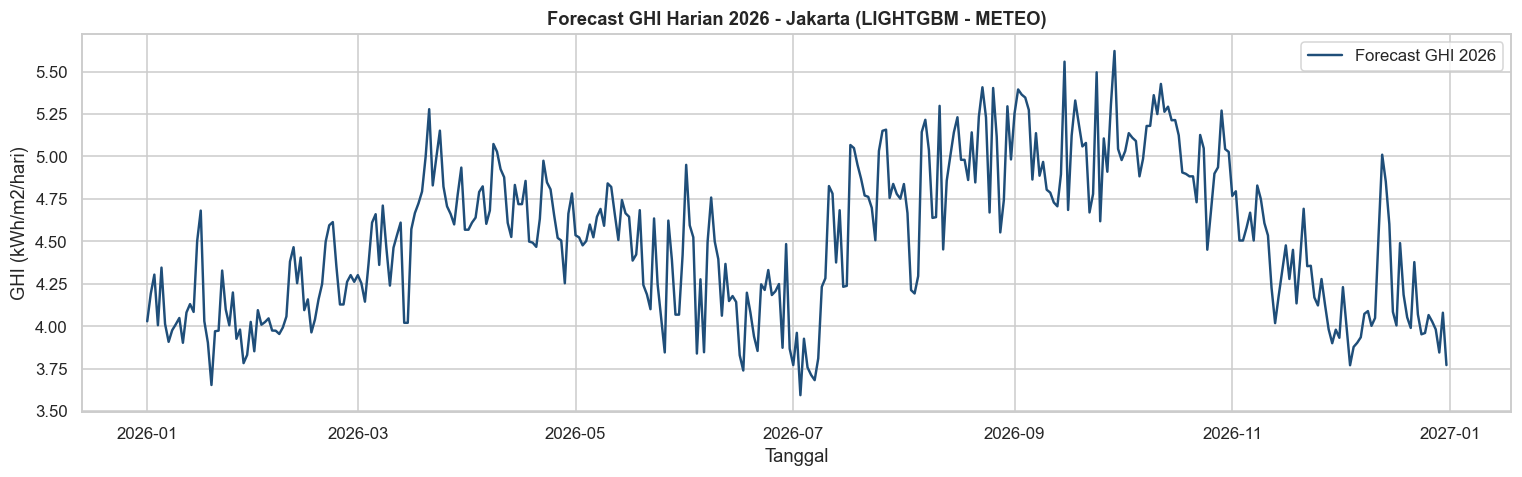

In [12]:
# ============================================================
#  6c-2. Ketidakpastian forecast GHI 2026 (Monte Carlo) + visualisasi forecast
# ============================================================
# Sampling TEMP/RH/PRECIP ~ N(mu_doy, sigma_doy) per hari, prediksi GHI,
# lalu ambil persentil harian (p10, p50, p90). Sigma berasal dari statistik
# climatology (bukan fitur model) -> murni untuk kuantifikasi ketidakpastian.

rng = np.random.default_rng(42)
N_MC = 300

# mu & sigma per hari (mengikuti urutan tanggal 2026)
mc_base = future[["doy"]].merge(
    climatology[["doy"]
                + [f"{v}_mean" for v in METEO_VARS]
                + [f"{v}_std" for v in METEO_VARS]],
    on="doy",
    how="left",
)

n_days = len(future)
samples_ghi = np.zeros((N_MC, n_days))

# Template fitur: temporal + spasial tetap; hanya meteo yang divariasikan
template = future[METEO_FEATURES].copy()

for i in range(N_MC):
    X_i = template.copy()
    for var in METEO_VARS:
        mu = mc_base[f"{var}_mean"].values
        sigma = mc_base[f"{var}_std"].values
        draw = rng.normal(mu, sigma)
        if var == "RH":
            draw = np.clip(draw, 0, 100)
        elif var == "PRECIP":
            draw = np.clip(draw, 0, None)
        X_i[var] = draw
    samples_ghi[i] = np.clip(tea_model.predict(X_i), 0, None)

ghi_p10 = np.percentile(samples_ghi, 10, axis=0)
ghi_p50 = np.percentile(samples_ghi, 50, axis=0)
ghi_p90 = np.percentile(samples_ghi, 90, axis=0)

annual_p10 = float(ghi_p10.sum())
annual_p50 = float(ghi_p50.sum())
annual_p90 = float(ghi_p90.sum())

print(f"Ketidakpastian GHI tahunan {FORECAST_YEAR} (Monte Carlo, N={N_MC}):")
print(f"  p10           : {annual_p10:,.1f} kWh/m2/thn")
print(f"  p50 (median)  : {annual_p50:,.1f} kWh/m2/thn")
print(f"  p90           : {annual_p90:,.1f} kWh/m2/thn")
print(f"  deterministik : {GHI_2026_annual:,.1f} kWh/m2/thn (climatology mean)")

# --- Visualisasi forecast GHI 2026 (tanpa pita ketidakpastian) ---
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(
    future["date"],
    future["GHI_pred"],
    color="#1f4e79",
    lw=1.6,
    label="Forecast GHI 2026",
)
ax.set_title(f"Forecast GHI Harian {FORECAST_YEAR} - {TARGET_NAME} "
             f"({TEA_ALGO.upper()} - METEO)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("GHI (kWh/m2/hari)")
ax.legend()
plt.tight_layout()

DIR_RESULTS.mkdir(parents=True, exist_ok=True)
fig.savefig(DIR_RESULTS / "forecast_ghi_2026.png", dpi=300, bbox_inches="tight")

plt.show()


In [13]:
# ============================================================
#  6c-3. POA & AEP forecast 2026  ->  basis TEA (Year-1)
# ============================================================
# Pipeline sama dengan Tahap 6b: GHI_2026 -> Erbs -> Perez -> POA -> AEP.
# Nilai baseline TEA (E_YEAR1, POA_YEAR1, GHI_YEAR1, SPECIFIC_YIELD)
# di-OVERRIDE agar berbasis FORECAST 2026, bukan rata-rata historis.

# --- Simpan baseline multi-tahun (2021-2025) untuk pembanding/backtest ---
GHI_MULTIYEAR = GHI_YEAR1
POA_MULTIYEAR = POA_YEAR1
AEP_MULTIYEAR = E_YEAR1
SPECIFIC_YIELD_MULTIYEAR = SPECIFIC_YIELD

# --- POA & AEP untuk forecast 2026 (central: climatology mean) ---
res_2026 = calculate_annual_poa_and_aep(
    daily_ghi=future["GHI_pred"].values,
    dates=future["date"].values,
    latitude=nearest["lat"],
    longitude=nearest["lon"],
    tilt=TILT,
    azimuth=AZIMUTH,
    albedo=ALBEDO,
    capacity_kwp=CAPACITY_KWP,
    pr=PERFORMANCE_RATIO,
)

# --- POA & AEP pada batas pita ketidakpastian (p10 & p90) ---
res_p10 = calculate_annual_poa_and_aep(
    daily_ghi=ghi_p10, dates=future["date"].values,
    latitude=nearest["lat"], longitude=nearest["lon"],
    tilt=TILT, azimuth=AZIMUTH, albedo=ALBEDO,
    capacity_kwp=CAPACITY_KWP, pr=PERFORMANCE_RATIO,
)
res_p90 = calculate_annual_poa_and_aep(
    daily_ghi=ghi_p90, dates=future["date"].values,
    latitude=nearest["lat"], longitude=nearest["lon"],
    tilt=TILT, azimuth=AZIMUTH, albedo=ALBEDO,
    capacity_kwp=CAPACITY_KWP, pr=PERFORMANCE_RATIO,
)

# --- OVERRIDE baseline TEA -> berbasis forecast 2026 ---
GHI_YEAR1 = GHI_2026_annual
POA_YEAR1 = res_2026["poa_annual"]
E_YEAR1 = res_2026["aep_kwh"]
SPECIFIC_YIELD = E_YEAR1 / CAPACITY_KWP

AEP_2026_P10 = res_p10["aep_kwh"]
AEP_2026_P90 = res_p90["aep_kwh"]
POA_2026_P10 = res_p10["poa_annual"]
POA_2026_P90 = res_p90["poa_annual"]

print("=" * 60)
print(f"BASELINE TEA = FORECAST {FORECAST_YEAR} (climatology-based)")
print("=" * 60)
print(f"  GHI 2026         : {GHI_YEAR1:,.1f} kWh/m2/thn")
print(f"  POA 2026         : {POA_YEAR1:,.1f} kWh/m2/thn "
      f"[p10 {POA_2026_P10:,.1f} - p90 {POA_2026_P90:,.1f}]")
print(f"  AEP 2026 (Year-1): {E_YEAR1:,.0f} kWh "
      f"[p10 {AEP_2026_P10:,.0f} - p90 {AEP_2026_P90:,.0f}]")
print(f"  Specific yield   : {SPECIFIC_YIELD:,.0f} kWh/kWp/thn")
print()
print("  Pembanding backtest multi-tahun (2021-2025):")
print(f"    AEP rata-rata  : {AEP_MULTIYEAR:,.0f} kWh")
print(f"    selisih        : {(E_YEAR1 - AEP_MULTIYEAR):+,.0f} kWh "
      f"({(E_YEAR1 / AEP_MULTIYEAR - 1) * 100:+.1f}%)")

# --- Simpan forecast harian 2026 ke CSV ---
forecast_out = future[["date", "day_of_year", "TEMP", "RH", "PRECIP", "GHI_pred"]].copy()
forecast_out = forecast_out.rename(columns={"GHI_pred": "GHI_forecast"})
forecast_out["GHI_p10"] = ghi_p10
forecast_out["GHI_p50"] = ghi_p50
forecast_out["GHI_p90"] = ghi_p90
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
forecast_out.to_csv(DIR_RESULTS / "forecast_ghi_2026.csv", index=False)
print(f"\n[OK] Forecast harian 2026 tersimpan -> forecast_ghi_2026.csv")


BASELINE TEA = FORECAST 2026 (climatology-based)
  GHI 2026         : 1,650.8 kWh/m2/thn
  POA 2026         : 1,651.1 kWh/m2/thn [p10 1,527.4 - p90 2,027.4]
  AEP 2026 (Year-1): 6,604 kWh [p10 6,110 - p90 8,110]
  Specific yield   : 1,321 kWh/kWp/thn

  Pembanding backtest multi-tahun (2021-2025):
    AEP rata-rata  : 6,896 kWh
    selisih        : -292 kWh (-4.2%)

[OK] Forecast harian 2026 tersimpan -> forecast_ghi_2026.csv


## 7. Analisis Kelayakan Finansial

Tahap ini menilai kelayakan proyek dengan **fokus pada dua indikator utama: AEP dan NPV**. Produksi Year-1 menggunakan **AEP hasil forecast tahun 2026** (climatology-based, lihat Tahap 6c). Rata-rata multi-tahun (2021–2025) dari Tahap 6b dipertahankan sebagai *backtest* pembanding dan dasar analisis robustness antar-model.

Indikator yang dihitung:
- **AEP** (*Annual Energy Production*): produksi energi tahunan (Year-1 = forecast 2026)
- **NPV** (*Net Present Value*): nilai sekarang dari seluruh arus kas proyek selama umur ekonomis. Proyek dinilai **layak** apabila NPV > 0.

Arus kas tahun ke-$n$: $\text{CF}_n = E_1 \times (1-d)^{n-1} \times f_{\text{self}} \times T_n - \text{OPEX}$

di mana $E_1$ = AEP Year-1 (forecast 2026), $d$ = degradasi, $f_{\text{self}}$ = self-consumption, $T_n$ = tarif tereskalasi.


In [14]:
# ---------- Fungsi finansial (implementasi manual) ----------

def npv(rate, cashflows):
    """
    Hitung Net Present Value.
    cashflows[0] adalah arus kas tahun-0 (mis. -CAPEX).
    """
    cf = np.asarray(cashflows, dtype=float)
    t = np.arange(len(cf))
    return np.sum(cf / (1 + rate) ** t)


# ---------- Profil Produksi 25 Tahun (Year-1 = forecast 2026) ----------

years = np.arange(1, LIFETIME_YEARS + 1)

# Year-1 production = AEP hasil forecast GHI 2026 (climatology-based)
energy_per_year = E_YEAR1 * (1 - DEGRADATION) ** (years - 1)

# Energi yang dipakai sendiri & tarif tereskalasi
energy_used = energy_per_year * SELF_CONSUMPTION
tariff_per_year = TARIFF * (1 + TARIFF_ESCALATION) ** (years - 1)
savings_per_year = energy_used * tariff_per_year

# Tabel profil energi
df_energy = pd.DataFrame({
    "tahun": years,
    "energi_kWh": energy_per_year.round(0),
    "energi_dipakai_kWh": energy_used.round(0),
    "tarif_Rp_kWh": tariff_per_year.round(0),
    "penghematan_Rp": savings_per_year.round(0),
})


# ---------- Susun arus kas 25 tahun ----------

net_cashflow_annual = savings_per_year - OPEX_ANNUAL
cashflows = np.concatenate([[-CAPEX_TOTAL], net_cashflow_annual])

# Faktor diskon (untuk kurva kumulatif terdiskon pada plot arus kas)
discount_factor = 1 / (1 + DISCOUNT_RATE) ** years
discounted_cashflows = np.concatenate(
    [[-CAPEX_TOTAL], net_cashflow_annual * discount_factor]
)


# ---------- Indikator kelayakan (fokus: AEP & NPV) ----------
project_npv = npv(DISCOUNT_RATE, cashflows)


# ---------- Tampilkan hasil ----------
print("=" * 60)
print("INDIKATOR KELAYAKAN FINANSIAL (fokus AEP & NPV)")
print("=" * 60)
print(f"Baseline AEP Year-1    : {E_YEAR1:,.0f} kWh (forecast {FORECAST_YEAR})")
print(f"Specific Yield         : {SPECIFIC_YIELD:,.0f} kWh/kWp/tahun")
print(f"Total energi 25 thn    : {energy_per_year.sum():,.0f} kWh")
print(f"Total penghematan 25y  : Rp {savings_per_year.sum():,.0f}")
print()
print(f"NPV (r={DISCOUNT_RATE:.0%})           : Rp {project_npv:,.0f}")
print(f"Status kelayakan       : {'LAYAK' if project_npv > 0 else 'TIDAK LAYAK'}")


INDIKATOR KELAYAKAN FINANSIAL (fokus AEP & NPV)
Baseline AEP Year-1    : 6,604 kWh (forecast 2026)
Specific Yield         : 1,321 kWh/kWp/tahun
Total energi 25 thn    : 155,569 kWh
Total penghematan 25y  : Rp 211,426,509

NPV (r=6%)           : Rp 15,912,640
Status kelayakan       : LAYAK


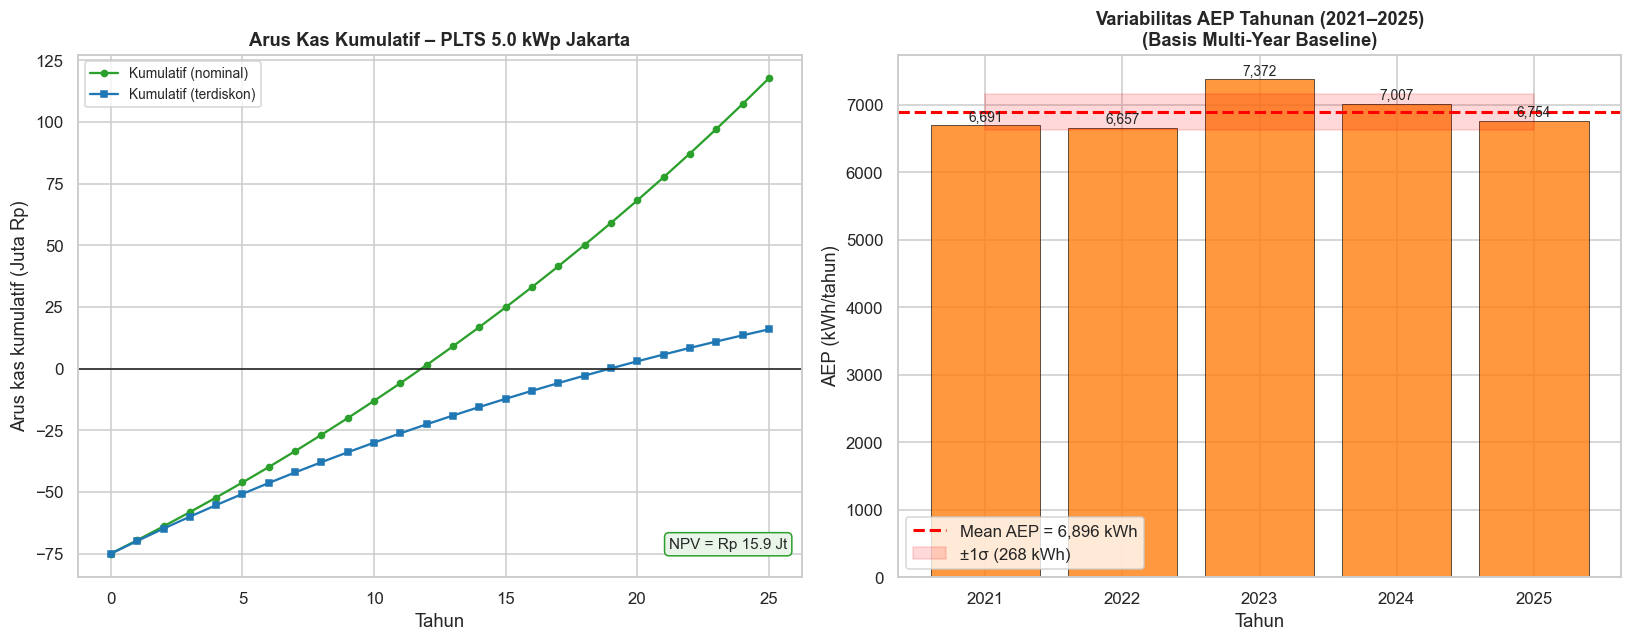

In [15]:
# Grafik arus kas kumulatif (jalur NPV) + profil produksi tahunan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel kiri: Arus kas kumulatif ---
year_axis = np.arange(0, LIFETIME_YEARS + 1)
cumulative_nominal = np.cumsum(cashflows)
cumulative_discounted = np.cumsum(discounted_cashflows)

ax1.plot(year_axis, cumulative_nominal / 1e6, "o-", label="Kumulatif (nominal)", color="#2ca02c", markersize=4)
ax1.plot(year_axis, cumulative_discounted / 1e6, "s-", label="Kumulatif (terdiskon)", color="#1f77b4", markersize=4)
ax1.axhline(0, color="k", lw=1)
ax1.text(0.98, 0.05, f"NPV = Rp {project_npv/1e6:,.1f} Jt",
         transform=ax1.transAxes, ha="right", va="bottom",
         fontsize=10, bbox=dict(boxstyle="round", fc="#eaf5ea", ec="#2ca02c"))

ax1.set_title(f"Arus Kas Kumulatif – PLTS {CAPACITY_KWP} kWp {TARGET_NAME}")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Arus kas kumulatif (Juta Rp)")
ax1.legend(fontsize=9)

# --- Panel kanan: Variabilitas AEP per tahun ---
year_labels = [str(y) for y in yearly_results.keys()]
aep_values = [v["aep_kwh"] for v in yearly_results.values()]

bars = ax2.bar(year_labels, aep_values, color="#ff7f0e", alpha=0.8, edgecolor="black", linewidth=0.5)
ax2.axhline(AEP_MULTIYEAR, color="red", ls="--", lw=2, label=f"Mean AEP = {AEP_MULTIYEAR:,.0f} kWh")
ax2.fill_between(
    range(len(year_labels)),
    AEP_MULTIYEAR - aep_annual_values.std(),
    AEP_MULTIYEAR + aep_annual_values.std(),
    alpha=0.15, color="red", label=f"±1σ ({aep_annual_values.std():,.0f} kWh)"
)
ax2.set_title("Variabilitas AEP Tahunan (2021–2025)\n(Basis Multi-Year Baseline)")
ax2.set_xlabel("Tahun")
ax2.set_ylabel("AEP (kWh/tahun)")
ax2.legend()

for bar, val in zip(bars, aep_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [16]:
def run_tea(
    annual_poa,
    *,
    capacity=CAPACITY_KWP,
    capex_per_kwp=CAPEX_PER_KWP,
    tariff=TARIFF,
    lifetime=LIFETIME_YEARS,
    discount=DISCOUNT_RATE,
    degradation=DEGRADATION,
    pr=PERFORMANCE_RATIO,
    self_cons=SELF_CONSUMPTION,
    opex_rate=OPEX_RATE,
    escalation=TARIFF_ESCALATION,
):
    """
    Jalankan TEA dari total POA tahunan (kWh/m2/thn) dan kembalikan
    AEP Year-1 (E_thn1_kWh) beserta NPV proyek. Fokus evaluasi kelayakan
    hanya pada AEP dan NPV.
    """
    capex = capacity * capex_per_kwp
    opex = opex_rate * capex

    years_local = np.arange(1, lifetime + 1)
    e1 = capacity * annual_poa * pr
    energy = e1 * (1 - degradation) ** (years_local - 1)

    tariff_year = tariff * (1 + escalation) ** (years_local - 1)
    savings = energy * self_cons * tariff_year
    net = savings - opex

    cf = np.concatenate([[-capex], net])
    npv_value = npv(discount, cf)

    return {
        "E_thn1_kWh": e1,
        "NPV": npv_value,
    }


# ============================================================
#  Robustness: TEA dengan POA dari tiap model + aktual
# ============================================================

robustness_rows = []

for algorithm in ALGORITHMS:
    # Muat model METEO untuk setiap algoritma
    algo_model_path = DIR_PROCESSED.parent / "models" / f"{algorithm}_METEO.pkl"
    if not algo_model_path.exists():
        algo_model_path = DIR_RESULTS.parent.parent / "models" / f"{algorithm}_METEO.pkl"

    algo_model = joblib.load(algo_model_path)

    # Prediksi GHI untuk semua tahun
    ghi_pred_algo = algo_model.predict(X_site)
    ghi_pred_algo = np.clip(ghi_pred_algo, 0, None)

    # Hitung POA multi-year average
    site_temp = site_data.copy()
    site_temp["GHI_algo"] = ghi_pred_algo

    poa_per_year = []
    for year in ALL_YEARS:
        year_mask = site_temp["year"] == year
        if year_mask.sum() == 0:
            continue
        year_subset = site_temp[year_mask]
        res = calculate_annual_poa_and_aep(
            daily_ghi=year_subset["GHI_algo"].values,
            dates=year_subset["date"].values,
            latitude=nearest["lat"],
            longitude=nearest["lon"],
            tilt=TILT,
            azimuth=AZIMUTH,
            albedo=ALBEDO,
            capacity_kwp=CAPACITY_KWP,
            pr=PERFORMANCE_RATIO,
        )
        poa_per_year.append(res["poa_annual"])

    mean_poa = np.mean(poa_per_year)
    result = run_tea(mean_poa)

    robustness_rows.append({
        "sumber": f"{algorithm.upper()}-METEO",
        "GHI_thn": round(site_temp["GHI_algo"].groupby(site_temp["year"]).sum().mean(), 1),
        "POA_thn": round(mean_poa, 1),
        **result,
    })


# Baris referensi: GHI aktual (jika tersedia di dataset)
if TARGET in site_data.columns:
    poa_actual_years = []
    for year in ALL_YEARS:
        year_mask = site_data["year"] == year
        if year_mask.sum() == 0:
            continue
        year_subset = site_data[year_mask]
        if year_subset[TARGET].isna().all():
            continue
        res = calculate_annual_poa_and_aep(
            daily_ghi=year_subset[TARGET].values,
            dates=year_subset["date"].values,
            latitude=nearest["lat"],
            longitude=nearest["lon"],
            tilt=TILT,
            azimuth=AZIMUTH,
            albedo=ALBEDO,
            capacity_kwp=CAPACITY_KWP,
            pr=PERFORMANCE_RATIO,
        )
        poa_actual_years.append(res["poa_annual"])

    if poa_actual_years:
        mean_poa_actual = np.mean(poa_actual_years)
        result_true = run_tea(mean_poa_actual)
        robustness_rows.append({
            "sumber": "AKTUAL (referensi)",
            "GHI_thn": round(site_data.groupby("year")[TARGET].sum().mean(), 1),
            "POA_thn": round(mean_poa_actual, 1),
            **result_true,
        })


robustness = pd.DataFrame(robustness_rows)

robustness_display = robustness.assign(
    NPV=lambda d: (d["NPV"] / 1e6).round(2),
    E_thn1_kWh=lambda d: d["E_thn1_kWh"].round(0),
).rename(columns={
    "NPV": "NPV_jutaRp",
    "E_thn1_kWh": "AEP_thn1_kWh",
    "POA_thn": "POA_kWh_m2_thn",
})

print("Robustness TEA: perbandingan antar model (multi-year average, POA-based):")
print("Fokus indikator: AEP Year-1 & NPV.")
display(robustness_display)
print("\n→ Baseline menggunakan rata-rata multi-tahun. Variabilitas ditunjukkan melalui CV pada Tahap 6.")


Robustness TEA: perbandingan antar model (multi-year average, POA-based):
Fokus indikator: AEP Year-1 & NPV.


,sumber,GHI_thn,POA_kWh_m2_thn,AEP_thn1_kWh,NPV_jutaRp
0,LIGHTGBM-METEO,1721.200000,1724.1,6896.0,20.36
1,XGBOOST-METEO,1711.900024,1714.0,6856.0,19.75
2,AKTUAL (referensi),1685.300000,1684.8,6739.0,17.97



→ Baseline menggunakan rata-rata multi-tahun. Variabilitas ditunjukkan melalui CV pada Tahap 6.


## 8. Analisis Sensitivitas

Tahap ini menguji ketahanan nilai NPV terhadap perubahan sebesar ±20% pada asumsi-asumsi kunci. Pengujian dilakukan secara *ceteris paribus* (satu parameter diubah pada satu waktu).

**Catatan penting:** Analisis sensitivitas menggunakan POA basis forecast 2026 (Tahap 6c) sebagai titik acuan, konsisten dengan seluruh pipeline yang telah memperhitungkan transposisi irradiance ke bidang modul.

NPV dasar: Rp 15,912,640 (basis POA forecast 2026)
POA basis: 1651.1 kWh/m²/thn

Tabel NPV (Juta Rp) per variasi parameter:


,-20%,-10%,+0%,+10%,+20%
CAPEX/kWp,32.83,24.37,15.91,7.45,-1.00
Tarif listrik,-4.19,5.86,15.91,25.96,36.01
Discount rate,28.84,22.07,15.91,10.32,5.22
Self-consumption,-4.19,5.86,15.91,25.96,36.01
POA (sumber daya),-4.19,5.86,15.91,25.96,36.01
Performance Ratio,-4.19,5.86,15.91,25.96,36.01


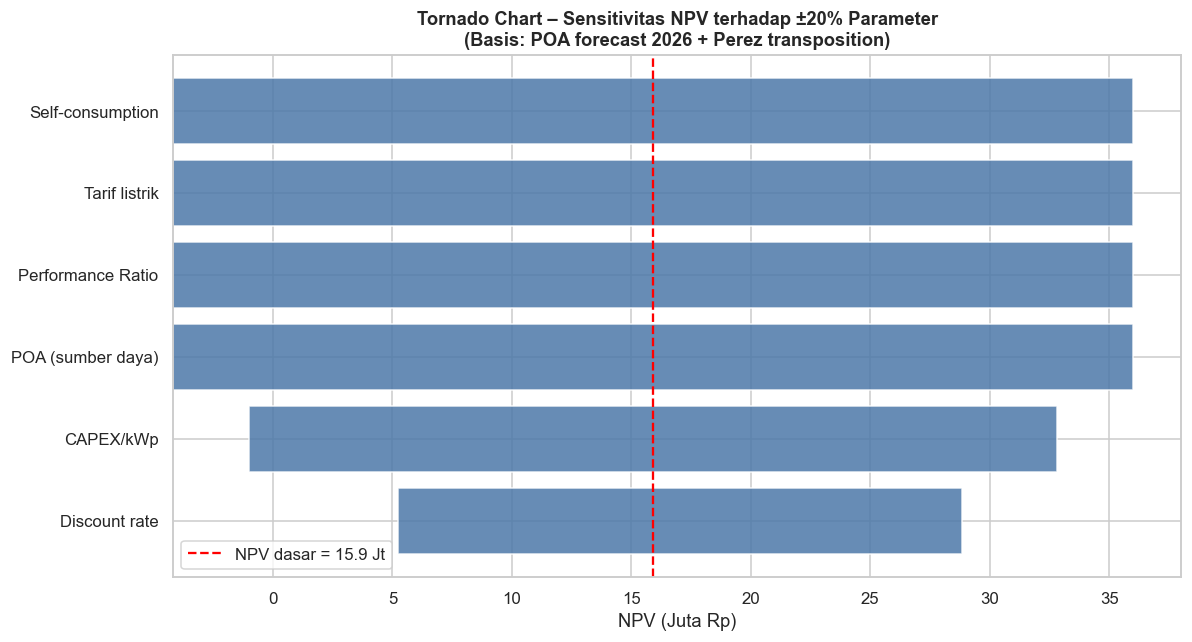

In [17]:
# Sensitivitas NPV terhadap ±20% tiap parameter (tornado)
# Basis: POA forecast 2026
POA_BASE = POA_YEAR1
npv_base = run_tea(POA_BASE)["NPV"]
variations = [-0.2, -0.1, 0.0, 0.1, 0.2]

param_tests = {
    "CAPEX/kWp":
        lambda f: run_tea(POA_BASE, capex_per_kwp=CAPEX_PER_KWP * (1 + f))["NPV"],
    "Tarif listrik":
        lambda f: run_tea(POA_BASE, tariff=TARIFF * (1 + f))["NPV"],
    "Discount rate":
        lambda f: run_tea(POA_BASE, discount=DISCOUNT_RATE * (1 + f))["NPV"],
    "Self-consumption":
        lambda f: run_tea(POA_BASE, self_cons=min(SELF_CONSUMPTION * (1 + f), 1.0))["NPV"],
    "POA (sumber daya)":
        lambda f: run_tea(POA_BASE * (1 + f))["NPV"],
    "Performance Ratio":
        lambda f: run_tea(POA_BASE, pr=min(PERFORMANCE_RATIO * (1 + f), 1.0))["NPV"],
}

sensitivity = pd.DataFrame(
    {name: [fn(f) / 1e6 for f in variations] for name, fn in param_tests.items()},
    index=[f"{int(v*100):+d}%" for v in variations],
).T

print(f"NPV dasar: Rp {npv_base:,.0f} (basis POA forecast 2026)")
print(f"POA basis: {POA_BASE:.1f} kWh/m²/thn\n")
print("Tabel NPV (Juta Rp) per variasi parameter:")
display(sensitivity.round(2))


# Tornado chart (rentang NPV pada ±20%)
npv_low = {name: param_tests[name](-0.2) / 1e6 for name in param_tests}
npv_high = {name: param_tests[name](0.2) / 1e6 for name in param_tests}
order = sorted(param_tests, key=lambda n: abs(npv_high[n] - npv_low[n]))
base_million = npv_base / 1e6

fig, ax = plt.subplots(figsize=(11, 6))

for i, name in enumerate(order):
    low_v, high_v = sorted([npv_low[name], npv_high[name]])
    ax.barh(i, high_v - low_v, left=low_v, color="#4c78a8", alpha=0.85)

ax.axvline(base_million, color="red", ls="--", label=f"NPV dasar = {base_million:.1f} Jt")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("NPV (Juta Rp)")
ax.set_title("Tornado Chart – Sensitivitas NPV terhadap ±20% Parameter\n(Basis: POA forecast 2026 + Perez transposition)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Ringkasan dan Penyimpanan Hasil

Tahap ini menyimpan seluruh hasil analisis ke folder `ml/data/results/`. Perubahan utama dari versi sebelumnya:
- Hasil TEA sekarang mencakup informasi transposisi POA dan statistik multi-tahun
- Baseline produksi Year-1 menggunakan forecast tahun 2026 (climatology-based); rata-rata multi-tahun disimpan sebagai backtest pembanding

In [18]:
# Susun ringkasan hasil TEA
tea_summary = {
    "metodologi": {
        "baseline": "forecast 2026 (climatology-based future covariates)",
        "future_covariates": "climatology day-of-year (2021-2025)",
        "uncertainty": f"Monte Carlo N={N_MC} pada TEMP/RH/PRECIP",
        "backtest": "multi-year average (2021-2025)",
        "transposisi": "Perez et al. (1990)",
        "dekomposisi": "Erbs et al. (1982)",
        "variabilitas": "CV berdasarkan 5 tahun data",
    },
    "lokasi_target": {
        "nama": TARGET_NAME,
        "lat": TARGET_LAT,
        "lon": TARGET_LON,
        "grid_id": TARGET_LOC_ID,
    },
    "model_terpilih": {
        "algoritma": TEA_ALGO,
        "skenario": TEA_SCENARIO,
        "model_terbaik_per_skenario": best_per_scenario,
    },
    "parameter_pv": {
        "capacity_kWp": CAPACITY_KWP,
        "tilt_deg": TILT,
        "azimuth_deg": AZIMUTH,
        "albedo": ALBEDO,
    },
    "parameter_ekonomi": {
        "capex_total": CAPEX_TOTAL,
        "tarif_Rp_kWh": TARIFF,
        "lifetime_thn": LIFETIME_YEARS,
        "discount_rate": DISCOUNT_RATE,
        "degradasi": DEGRADATION,
        "performance_ratio": PERFORMANCE_RATIO,
        "self_consumption": SELF_CONSUMPTION,
        "opex_rate": OPEX_RATE,
        "eskalasi_tarif": TARIFF_ESCALATION,
    },
    "sumber_daya_multiyear": {
        "tahun_analisis": ALL_YEARS,
        "GHI_mean_kWh_m2_thn": float(GHI_MULTIYEAR),
        "GHI_std": float(ghi_annual_values.std()),
        "GHI_cv_pct": float(ghi_annual_values.std() / ghi_annual_values.mean() * 100),
        "POA_mean_kWh_m2_thn": float(POA_MULTIYEAR),
        "POA_std": float(poa_annual_values.std()),
        "POA_cv_pct": float(poa_annual_values.std() / poa_annual_values.mean() * 100),
        "AEP_mean_kWh": float(AEP_MULTIYEAR),
        "AEP_std": float(aep_annual_values.std()),
        "AEP_cv_pct": float(aep_annual_values.std() / aep_annual_values.mean() * 100),
    },
    "forecast_2026": {
        "tahun": FORECAST_YEAR,
        "metode_covariate": "climatology day-of-year (mean) dari 2021-2025",
        "GHI_kWh_m2_thn": float(GHI_YEAR1),
        "GHI_p10": float(annual_p10),
        "GHI_p50": float(annual_p50),
        "GHI_p90": float(annual_p90),
        "POA_kWh_m2_thn": float(POA_YEAR1),
        "POA_p10": float(POA_2026_P10),
        "POA_p90": float(POA_2026_P90),
        "AEP_kWh": float(E_YEAR1),
        "AEP_p10": float(AEP_2026_P10),
        "AEP_p90": float(AEP_2026_P90),
        "specific_yield_kWh_kWp": float(SPECIFIC_YIELD),
        "monte_carlo_N": int(N_MC),
    },
    "energi": {
        "POA_thn_kWh_m2": float(POA_YEAR1),
        "E_tahun1_kWh": float(E_YEAR1),
        "specific_yield_kWh_kWp": float(SPECIFIC_YIELD),
    },
    "indikator": {
        "NPV": float(project_npv),
        "layak": bool(project_npv > 0),
    },
}


# Simpan seluruh artefak hasil ke folder results
DIR_RESULTS.mkdir(parents=True, exist_ok=True)

with open(DIR_RESULTS / "tea_summary.json", "w", encoding="utf-8") as file:
    json.dump(tea_summary, file, indent=2, ensure_ascii=False)

comparison.to_csv(DIR_RESULTS / "model_comparison.csv", index=False)
df_energy.to_csv(DIR_RESULTS / "tea_energy_profile.csv", index=False)
robustness.to_csv(DIR_RESULTS / "tea_model_robustness.csv", index=False)

print("Tersimpan ke", DIR_RESULTS)
for file_name in [
    "tea_summary.json",
    "model_comparison.csv",
    "tea_energy_profile.csv",
    "tea_model_robustness.csv",
    "forecast_ghi_2026.csv",
]:
    print("  •", file_name)


Tersimpan ke ..\data\results
  • tea_summary.json
  • model_comparison.csv
  • tea_energy_profile.csv
  • tea_model_robustness.csv
  • forecast_ghi_2026.csv


## 10. Kesimpulan

**Perbaikan metodologi yang diterapkan:**
1. **Forecast 2026 sebagai baseline:** Produksi energi Year-1 menggunakan hasil *forecasting* GHI tahun 2026 yang variabel meteorologinya dibangun dari climatology *day-of-year* (2021–2025). Rata-rata multi-tahun 2021–2025 dipertahankan sebagai *backtest* pembanding untuk menilai kewajaran forecast.
2. **Transposisi POA:** Pipeline sekarang mengikuti standar internasional: GHI → Dekomposisi Erbs → Transposisi Perez → POA → AEP. Tanpa tahap ini, produksi energi cenderung *underestimate* karena modul yang dimiringkan menerima radiasi lebih banyak dari bidang horizontal.
3. **Statistik variabilitas:** Dilaporkan koefisien variasi (CV) yang mencerminkan ketidakpastian sumber daya surya antar-tahun.

**Hasil utama:**
- **Komparasi model:** LightGBM dan XGBoost menghasilkan akurasi yang berdekatan. Skenario METEO digunakan untuk TEA karena skenario FULL bersifat *circular* ($GHI \approx DHI + DNI \cos\theta_z$).
- **Evaluasi kelayakan (PLTS Atap 5 kWp):** Difokuskan pada dua indikator utama, yaitu **AEP** (produksi energi tahunan) dan **NPV**, dihitung menggunakan pipeline POA-based dengan baseline forecast 2026 (climatology-based). Proyek dinilai layak apabila NPV > 0, dan hasilnya stabil terhadap pilihan algoritma.
- **Sensitivitas:** NPV paling dipengaruhi oleh tarif listrik, CAPEX, dan POA (sumber daya surya).

**Implikasi:** Sistem TEA berbasis machine learning dapat menilai kelayakan PLTS Atap pada koordinat mana pun di Pulau Jawa menggunakan hanya data meteorologis (tanpa pengukuran irradiance langsung). Metodologi yang digunakan telah mengikuti standar pemodelan performa PV internasional (IEC 61724, pvlib).

> *Seluruh angka final akan muncul setelah seluruh sel dijalankan.*
